## 1. Data Setup

In [1]:
# 1.1 Create GCS bucket
# gsutil mb -p our-signal-485215-f3 gs://st446-so2-data/

# 1.2 Copy data from M1
# gsutil -m cp -r gs://gds-so2-pipeline-data/tropomi/SO2/ gs://st446-so2-data/tropomi/SO2/
# gsutil -m cp -r gs://gds-so2-pipeline-data/tropomi/NO2/ gs://st446-so2-data/tropomi/NO2/
# gsutil -m cp -r gs://gds-so2-pipeline-data/era5/        gs://st446-so2-data/era5/

# 1.3 Copy Fioletov catalogue from M2 bucket
# gsutil cp gs://st446-m2-outputs/fioletov_catalogue.csv gs://st446-so2-data/fioletov_catalogue.csv

# 1.4 Verify bucket contents
# gsutil ls gs://st446-so2-data/
# gsutil du -sh gs://st446-so2-data/tropomi/SO2/
# gsutil du -sh gs://st446-so2-data/tropomi/NO2/
# gsutil du -sh gs://st446-so2-data/era5/

# Results:
# SO2:  425 files, 11.4 GiB
# NO2:  422 files, 7.2  GiB
# ERA5: 30  files, 3.0  GiB
print("Data paths:")
print("SO2  : gs://st446-so2-data/tropomi/SO2/YYYY-MM-DD/*.parquet")
print("NO2  : gs://st446-so2-data/tropomi/NO2/YYYY-MM-DD/*.parquet")
print("ERA5 : gs://st446-so2-data/era5/era5/wind_850hpa/*.parquet")
print("Cat  : gs://st446-so2-data/fioletov_catalogue.csv")

Data paths:
SO2  : gs://st446-so2-data/tropomi/SO2/YYYY-MM-DD/*.parquet
NO2  : gs://st446-so2-data/tropomi/NO2/YYYY-MM-DD/*.parquet
ERA5 : gs://st446-so2-data/era5/era5/wind_850hpa/*.parquet
Cat  : gs://st446-so2-data/fioletov_catalogue.csv


## 2. Cluster

In [2]:
# Quota increases obtained before running experiments

# Cluster creation 
cluster_commands = {
    "2w (europe-west2)": """
gcloud dataproc clusters create so2-scaling-2w \
  --region=europe-west2 --master-machine-type=n2-standard-4 \
  --worker-machine-type=n2-standard-4 --num-workers=2 \
  --master-boot-disk-size=100GB --worker-boot-disk-size=100GB \
  --image-version=2.1-debian11 --project=our-signal-485215-f3""",

    "4w (europe-west1)": """
gcloud dataproc clusters create so2-scaling-4w \
  --region=europe-west1 --master-machine-type=n2-standard-4 \
  --worker-machine-type=n2-standard-4 --num-workers=4 \
  --master-boot-disk-size=100GB --worker-boot-disk-size=100GB \
  --image-version=2.1-debian11 --project=our-signal-485215-f3""",

    "8w (europe-west1)": """
gcloud dataproc clusters create so2-scaling-8w \
  --region=europe-west1 --master-machine-type=n2-standard-4 \
  --worker-machine-type=n2-standard-4 --num-workers=8 \
  --master-boot-disk-size=100GB --worker-boot-disk-size=100GB \
  --image-version=2.1-debian11 --project=our-signal-485215-f3""",

    "16w (europe-west1)": """
gcloud dataproc clusters create so2-scaling-16w \
  --region=europe-west1 --master-machine-type=n2-standard-4 \
  --worker-machine-type=n2-standard-4 --num-workers=16 \
  --master-boot-disk-size=100GB --worker-boot-disk-size=100GB \
  --image-version=2.1-debian11 --project=our-signal-485215-f3"""
}

# Job submission commands (strong scaling)
strong_job_commands = [
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_scaling_job.py --cluster=so2-scaling-2w  --region=europe-west2 --project=our-signal-485215-f3 --async -- --workers=2",
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_scaling_job.py --cluster=so2-scaling-4w  --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=4",
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_scaling_job.py --cluster=so2-scaling-8w  --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=8",
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_scaling_job.py --cluster=so2-scaling-16w --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=16",
]

# Job submission commands (weak scaling)
weak_job_commands = [
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_weak_scaling_job.py --cluster=so2-scaling-2w  --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=2  --days=1",
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_weak_scaling_job.py --cluster=so2-scaling-4w  --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=4  --days=2",
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_weak_scaling_job.py --cluster=so2-scaling-8w  --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=8  --days=4",
    "gcloud dataproc jobs submit pyspark gs://st446-so2-data/jobs/so2_weak_scaling_job.py --cluster=so2-scaling-16w --region=europe-west1 --project=our-signal-485215-f3 --async -- --workers=16 --days=8",
]

print("Cluster and job commands defined.")
print(f"Strong scaling runs: {len(strong_job_commands)}")
print(f"Weak scaling runs:   {len(weak_job_commands)}")

Cluster and job commands defined.
Strong scaling runs: 4
Weak scaling runs:   4


## 3. Experiment Results

In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Strong Scaling Results (from gs://st446-so2-data/scaling_results/) 
strong_results = {
    2:  {"total_elapsed_s": 24415.76, "timings": {"stage1_data_load": 399.28,  "stage2_colocation": 383.73,  "stage3_era5_join": 1402.24, "stage4_labelling": 8253.33,  "stage5_gbt": 13977.18}, "metrics": {"auc_roc": 0.9994, "f1": 0.9897, "accuracy": 0.9895}},
    4:  {"total_elapsed_s": 7195.73,  "timings": {"stage1_data_load": 25.51,   "stage2_colocation": 110.43,  "stage3_era5_join": 313.59,  "stage4_labelling": 2424.21,  "stage5_gbt": 4321.99},  "metrics": {"auc_roc": 0.9993, "f1": 0.9893, "accuracy": 0.9891}},
    8:  {"total_elapsed_s": 3598.44,  "timings": {"stage1_data_load": 19.80,   "stage2_colocation": 56.06,   "stage3_era5_join": 132.43,  "stage4_labelling": 1045.64,  "stage5_gbt": 2344.51},  "metrics": {"auc_roc": 0.9993, "f1": 0.9893, "accuracy": 0.9891}},
    16: {"total_elapsed_s": 1816.71,  "timings": {"stage1_data_load": 23.95,   "stage2_colocation": 51.36,   "stage3_era5_join": 85.74,   "stage4_labelling": 547.55,   "stage5_gbt": 1108.11},  "metrics": {"auc_roc": 0.9993, "f1": 0.9893, "accuracy": 0.9891}},
}

# Weak Scaling Results (from gs://st446-so2-data/weak_scaling_results/)
weak_results = {
    (2,1):  {"total_elapsed_s": 2437.24, "timings": {"stage1_data_load": 18.77, "stage2_colocation": 62.58,  "stage3_era5_join": 28.21,  "stage4_labelling": 773.32,  "stage5_gbt": 1554.36}, "metrics": {"auc_roc": 1.0000, "f1": 0.9983}},
    (4,2):  {"total_elapsed_s": 2262.80, "timings": {"stage1_data_load": 19.57, "stage2_colocation": 68.67,  "stage3_era5_join": 30.40,  "stage4_labelling": 722.36,  "stage5_gbt": 1421.80}, "metrics": {"auc_roc": 0.9999, "f1": 0.9940}},
    (8,4):  {"total_elapsed_s": 2921.70, "timings": {"stage1_data_load": 25.19, "stage2_colocation": 73.36,  "stage3_era5_join": 37.51,  "stage4_labelling": 923.32,  "stage5_gbt": 1862.32}, "metrics": {"auc_roc": 0.9995, "f1": 0.9907}},
    (16,8): {"total_elapsed_s": 3131.98, "timings": {"stage1_data_load": 28.12, "stage2_colocation": 75.38,  "stage3_era5_join": 42.35,  "stage4_labelling": 965.61,  "stage5_gbt": 2020.52}, "metrics": {"auc_roc": 0.9992, "f1": 0.9845}},
}

stages       = ['stage1_data_load','stage2_colocation','stage3_era5_join','stage4_labelling','stage5_gbt']
stage_labels = ['Data Load','SO2/NO2 Co-location','ERA5 Wind Join','Fioletov Labelling','GBT Training']
stage_colors = ['#2E8B57','#1B4F8A','#B8860B','#6A5ACD','#C0392B']
workers      = [2, 4, 8, 16]
weak_keys    = [(2,1),(4,2),(8,4),(16,8)]

print("Results loaded successfully.")

Results loaded successfully.


## 4. Strong Scaling Results 

In [4]:
total_times    = [strong_results[w]['total_elapsed_s'] for w in workers]
baseline       = total_times[0]
actual_speedup = [baseline / t for t in total_times]
ideal_speedup  = [w / workers[0] for w in workers]
efficiency     = [a / i * 100 for a, i in zip(actual_speedup, ideal_speedup)]

# Summary table
print("Strong Scaling Summary")
print("=" * 72)
print(f"{'Workers':<10} {'Total (s)':>12} {'Total (hrs)':>13} {'Speedup':>10} {'Ideal':>8} {'Efficiency':>12}")
print("-" * 72)
for w, t, s, i, e in zip(workers, total_times, actual_speedup, ideal_speedup, efficiency):
    print(f"{w:<10} {t:>12.1f} {t/3600:>13.2f} {s:>10.2f}x {i:>8.1f}x {e:>11.1f}%")

print("\nPer-Stage Timings (seconds)")
print("=" * 78)
print(f"{'Stage':<25}" + "".join([f"{w:>13}w" for w in workers]) + f"{'2w->16w':>10}")
print("-" * 78)
for stage, label in zip(stages, stage_labels):
    times = [strong_results[w]['timings'][stage] for w in workers]
    spdup = times[0] / times[-1]
    print(f"{label:<25}" + "".join([f"{t:>14.1f}" for t in times]) + f"{spdup:>9.1f}x")

Strong Scaling Summary
Workers       Total (s)   Total (hrs)    Speedup    Ideal   Efficiency
------------------------------------------------------------------------
2               24415.8          6.78       1.00x      1.0x       100.0%
4                7195.7          2.00       3.39x      2.0x       169.7%
8                3598.4          1.00       6.79x      4.0x       169.6%
16               1816.7          0.50      13.44x      8.0x       168.0%

Per-Stage Timings (seconds)
Stage                                2w            4w            8w           16w   2w->16w
------------------------------------------------------------------------------
Data Load                         399.3          25.5          19.8          23.9     16.7x
SO2/NO2 Co-location               383.7         110.4          56.1          51.4      7.5x
ERA5 Wind Join                   1402.2         313.6         132.4          85.7     16.4x
Fioletov Labelling               8253.3        2424.2        1045

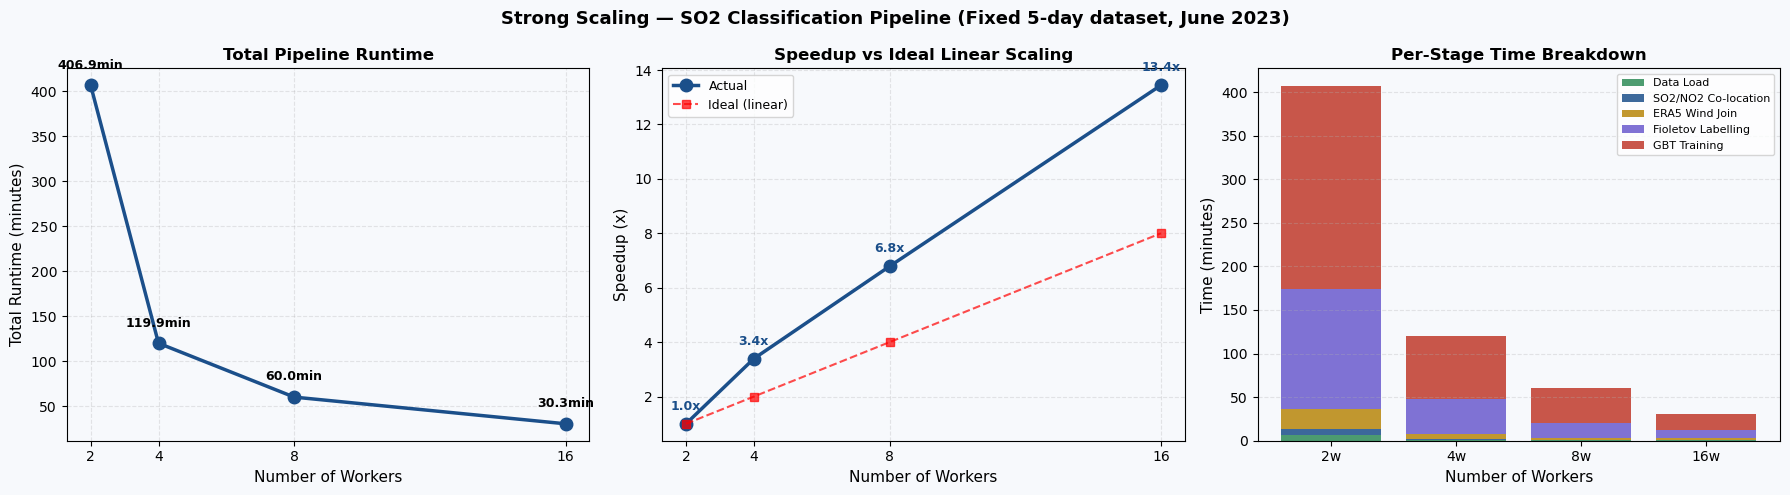

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.patch.set_facecolor('#F7F9FC')
for ax in axes:
    ax.set_facecolor('#F7F9FC')
fig.suptitle('Strong Scaling — SO2 Classification Pipeline (Fixed 5-day dataset, June 2023)',
             fontsize=13, fontweight='bold')

# Plot 1: Total runtime
axes[0].plot(workers, [t/60 for t in total_times], 'o-',
             color='#1B4F8A', linewidth=2.5, markersize=9)
axes[0].set_xlabel('Number of Workers', fontsize=11)
axes[0].set_ylabel('Total Runtime (minutes)', fontsize=11)
axes[0].set_title('Total Pipeline Runtime', fontweight='bold')
axes[0].set_xticks(workers)
axes[0].grid(True, alpha=0.3, linestyle='--')
for w, t in zip(workers, total_times):
    axes[0].annotate(f'{t/60:.1f}min', (w, t/60),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9, fontweight='bold')

# Plot 2: Speedup
axes[1].plot(workers, actual_speedup, 'o-', color='#1B4F8A',
             linewidth=2.5, markersize=9, label='Actual')
axes[1].plot(workers, ideal_speedup, 's--', color='red',
             linewidth=1.5, markersize=6, alpha=0.7, label='Ideal (linear)')
axes[1].set_xlabel('Number of Workers', fontsize=11)
axes[1].set_ylabel('Speedup (x)', fontsize=11)
axes[1].set_title('Speedup vs Ideal Linear Scaling', fontweight='bold')
axes[1].set_xticks(workers)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--')
for w, s in zip(workers, actual_speedup):
    axes[1].annotate(f'{s:.1f}x', (w, s),
                     textcoords='offset points', xytext=(0, 10),
                     ha='center', fontsize=9, fontweight='bold', color='#1B4F8A')

# Plot 3: Stacked stage breakdown
bottom = np.zeros(len(workers))
x = np.arange(len(workers))
for stage, label, color in zip(stages, stage_labels, stage_colors):
    times = np.array([strong_results[w]['timings'][stage]/60 for w in workers])
    axes[2].bar(x, times, bottom=bottom, label=label, color=color, alpha=0.85)
    bottom += times
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'{w}w' for w in workers])
axes[2].set_xlabel('Number of Workers', fontsize=11)
axes[2].set_ylabel('Time (minutes)', fontsize=11)
axes[2].set_title('Per-Stage Time Breakdown', fontweight='bold')
axes[2].legend(fontsize=8, loc='upper right')
axes[2].grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('strong_scaling_plots.png', dpi=150, bbox_inches='tight')
plt.show()

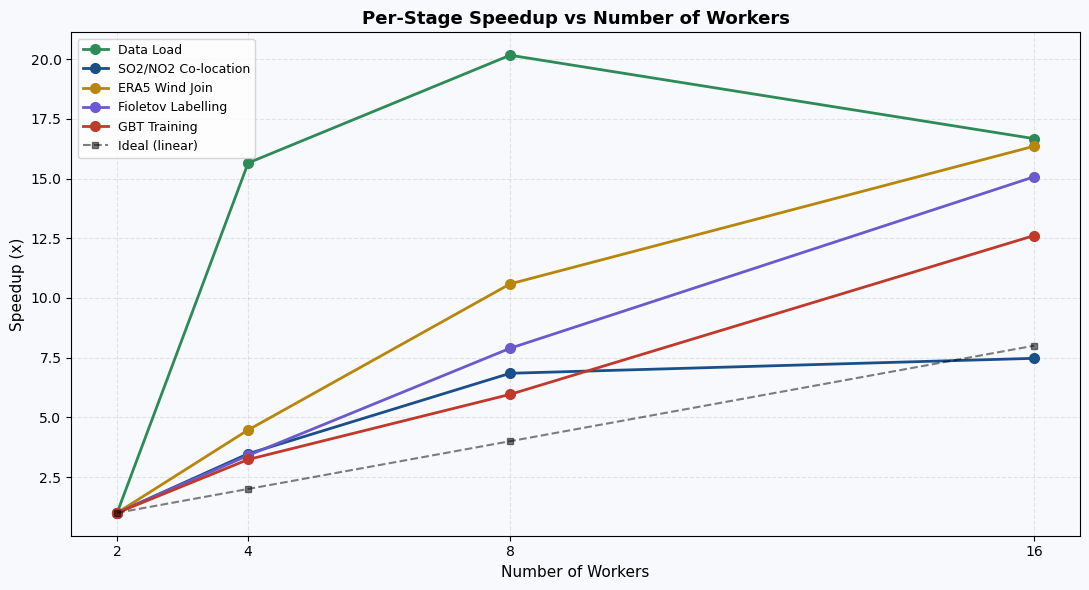

In [6]:
# Per-stage speedup lines
fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor('#F7F9FC')
ax.set_facecolor('#F7F9FC')

for stage, label, color in zip(stages, stage_labels, stage_colors):
    t_base = strong_results[2]['timings'][stage]
    speedups = [t_base / strong_results[w]['timings'][stage] for w in workers]
    ax.plot(workers, speedups, 'o-', linewidth=2, markersize=7, color=color, label=label)

ax.plot(workers, ideal_speedup, 's--', color='black',
        linewidth=1.5, markersize=5, alpha=0.5, label='Ideal (linear)')
ax.set_xlabel('Number of Workers', fontsize=11)
ax.set_ylabel('Speedup (x)', fontsize=11)
ax.set_title('Per-Stage Speedup vs Number of Workers', fontweight='bold', fontsize=13)
ax.set_xticks(workers)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('stage_speedup_plot.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Weak Scaling Results 

In [7]:
weak_times      = [weak_results[k]['total_elapsed_s'] for k in weak_keys]
weak_baseline   = weak_times[0]
weak_normalised = [t / weak_baseline for t in weak_times]
weak_workers    = [k[0] for k in weak_keys]
weak_days       = [k[1] for k in weak_keys]

print("Weak Scaling Summary (0.5 days per worker)")
print("=" * 65)
print(f"{'Workers':<10} {'Days':>6} {'Total (s)':>12} {'Total (min)':>13} {'Normalised':>12}")
print("-" * 65)
for w, d, t, n in zip(weak_workers, weak_days, weak_times, weak_normalised):
    print(f"{w:<10} {d:>6} {t:>12.1f} {t/60:>13.1f} {n:>12.2f}x")

print("\nPer-Stage Timings (seconds)")
print("=" * 75)
print(f"{'Stage':<25}" + "".join([f"{w}w/{d}d".rjust(12) for w,d in zip(weak_workers,weak_days)]))
print("-" * 75)
for stage, label in zip(stages, stage_labels):
    times = [weak_results[k]['timings'][stage] for k in weak_keys]
    print(f"{label:<25}" + "".join([f"{t:>12.1f}" for t in times]))

Weak Scaling Summary (0.5 days per worker)
Workers      Days    Total (s)   Total (min)   Normalised
-----------------------------------------------------------------
2               1       2437.2          40.6         1.00x
4               2       2262.8          37.7         0.93x
8               4       2921.7          48.7         1.20x
16              8       3132.0          52.2         1.29x

Per-Stage Timings (seconds)
Stage                           2w/1d       4w/2d       8w/4d      16w/8d
---------------------------------------------------------------------------
Data Load                        18.8        19.6        25.2        28.1
SO2/NO2 Co-location              62.6        68.7        73.4        75.4
ERA5 Wind Join                   28.2        30.4        37.5        42.4
Fioletov Labelling              773.3       722.4       923.3       965.6
GBT Training                   1554.4      1421.8      1862.3      2020.5


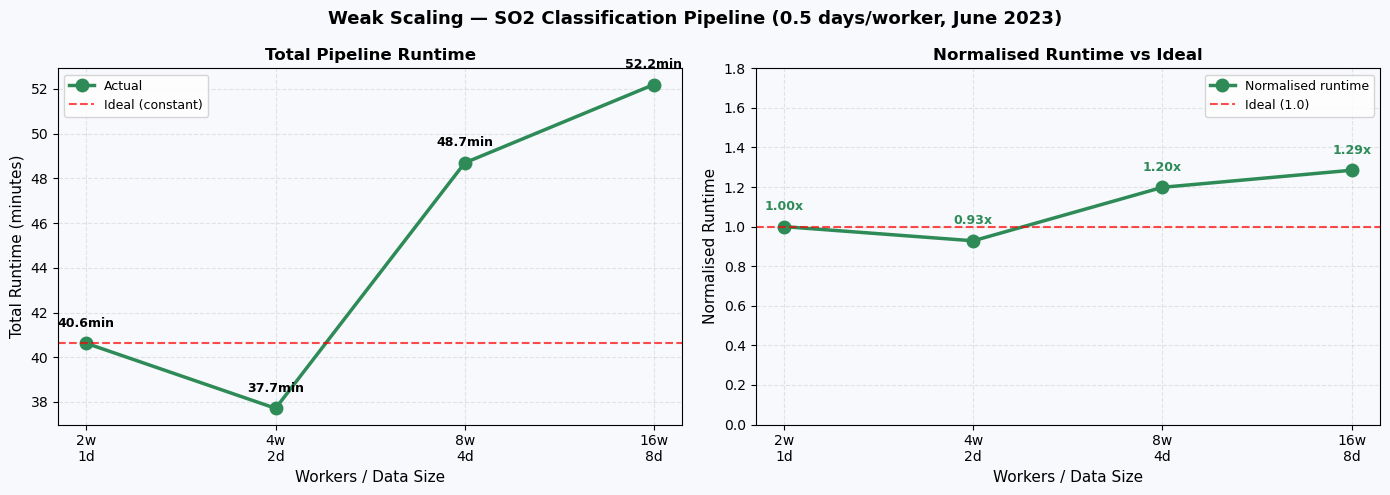

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F7F9FC')
for ax in axes:
    ax.set_facecolor('#F7F9FC')
fig.suptitle('Weak Scaling — SO2 Classification Pipeline (0.5 days/worker, June 2023)',
             fontsize=13, fontweight='bold')

x_labels = [f'{w}w\n{d}d' for w, d in zip(weak_workers, weak_days)]
x = np.arange(len(weak_keys))

# Plot 1: Absolute runtime
axes[0].plot(x, [t/60 for t in weak_times], 'o-',
             color='#2E8B57', linewidth=2.5, markersize=9, label='Actual')
axes[0].axhline(y=weak_baseline/60, color='red', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Ideal (constant)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(x_labels, fontsize=10)
axes[0].set_xlabel('Workers / Data Size', fontsize=11)
axes[0].set_ylabel('Total Runtime (minutes)', fontsize=11)
axes[0].set_title('Total Pipeline Runtime', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--')
for xi, t in zip(x, weak_times):
    axes[0].annotate(f'{t/60:.1f}min', (xi, t/60),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9, fontweight='bold')

# Plot 2: Normalised
axes[1].plot(x, weak_normalised, 'o-',
             color='#2E8B57', linewidth=2.5, markersize=9, label='Normalised runtime')
axes[1].axhline(y=1.0, color='red', linestyle='--',
                linewidth=1.5, alpha=0.7, label='Ideal (1.0)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, fontsize=10)
axes[1].set_xlabel('Workers / Data Size', fontsize=11)
axes[1].set_ylabel('Normalised Runtime', fontsize=11)
axes[1].set_title('Normalised Runtime vs Ideal', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 1.8)
axes[1].grid(True, alpha=0.3, linestyle='--')
for xi, n in zip(x, weak_normalised):
    axes[1].annotate(f'{n:.2f}x', (xi, n),
                     textcoords='offset points', xytext=(0, 12),
                     ha='center', fontsize=9, fontweight='bold', color='#2E8B57')

plt.tight_layout()
plt.savefig('weak_scaling_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bottleneck Analysis

In [9]:
print("Stage Proportion of Total Runtime (Strong Scaling)")
print("=" * 75)
print(f"{'Stage':<25}" + "".join([f"{w:>12}w" for w in workers]))
print("-" * 75)
for stage, label in zip(stages, stage_labels):
    props = [strong_results[w]['timings'][stage] / strong_results[w]['total_elapsed_s'] * 100
             for w in workers]
    print(f"{label:<25}" + "".join([f"{p:>11.1f}%" for p in props]))

print("\nKey Findings:")
gbt_2w  = strong_results[2]['timings']['stage5_gbt'] / strong_results[2]['total_elapsed_s'] * 100
lab_2w  = strong_results[2]['timings']['stage4_labelling'] / strong_results[2]['total_elapsed_s'] * 100
era5_su = strong_results[2]['timings']['stage3_era5_join'] / strong_results[16]['timings']['stage3_era5_join']
ovr_su  = strong_results[2]['total_elapsed_s'] / strong_results[16]['total_elapsed_s']
weak_deg = (weak_times[-1] - weak_times[0]) / weak_times[0] * 100



Stage Proportion of Total Runtime (Strong Scaling)
Stage                               2w           4w           8w          16w
---------------------------------------------------------------------------
Data Load                        1.6%        0.4%        0.6%        1.3%
SO2/NO2 Co-location              1.6%        1.5%        1.6%        2.8%
ERA5 Wind Join                   5.7%        4.4%        3.7%        4.7%
Fioletov Labelling              33.8%       33.7%       29.1%       30.1%
GBT Training                    57.2%       60.1%       65.2%       61.0%

Key Findings:


## 7. ML Performance Consistency

In [10]:
print("ML Performance — Strong Scaling")
print("=" * 48)
print(f"{'Workers':<10} {'AUC-ROC':>10} {'F1':>10} {'Accuracy':>10}")
print("-" * 48)
for w in workers:
    m = strong_results[w]['metrics']
    print(f"{w:<10} {m['auc_roc']:>10.4f} {m['f1']:>10.4f} {m['accuracy']:>10.4f}")

print("\nML Performance — Weak Scaling")
print("=" * 40)
print(f"{'Config':<12} {'AUC-ROC':>10} {'F1':>10}")
print("-" * 40)
for k in weak_keys:
    m = weak_results[k]['metrics']
    print(f"{k[0]}w/{k[1]}d{'':<5} {m['auc_roc']:>10.4f} {m['f1']:>10.4f}")



ML Performance — Strong Scaling
Workers       AUC-ROC         F1   Accuracy
------------------------------------------------
2              0.9994     0.9897     0.9895
4              0.9993     0.9893     0.9891
8              0.9993     0.9893     0.9891
16             0.9993     0.9893     0.9891

ML Performance — Weak Scaling
Config          AUC-ROC         F1
----------------------------------------
2w/1d          1.0000     0.9983
4w/2d          0.9999     0.9940
8w/4d          0.9995     0.9907
16w/8d          0.9992     0.9845


## 8. Partitioning Strategy Comparison

In [11]:

# Compare per-stage timings at equivalent worker counts


labelled_rows_strong = {2: 27033532, 4: 13636827, 8: 13636827, 16: 13636827}
labelled_rows_weak   = {(2,1): 2105893, (4,2): 4894789, (8,4): 10831415, (16,8): 21333974}

partitions_strong = {2: 400, 4: 400, 8: 400, 16: 400}
partitions_weak   = {(2,1): 100, (4,2): 200, (8,4): 400, (16,8): 800}

print("Partitioning Strategy Overview")
print("=" * 60)
print(f"{'Config':<15} {'Strategy':<25} {'Partitions':>12} {'Workers':>10}")
print("-" * 60)
for w in workers:
    print(f"Strong {w}w{'':<7} {'Fixed (400)':<25} {400:>12} {w:>10}")
for (w,d), p in partitions_weak.items():
    print(f"Weak {w}w/{d}d{'':<6} {f'Proportional ({w}x50)':<25} {p:>12} {w:>10}")



Partitioning Strategy Overview
Config          Strategy                    Partitions    Workers
------------------------------------------------------------
Strong 2w        Fixed (400)                        400          2
Strong 4w        Fixed (400)                        400          4
Strong 8w        Fixed (400)                        400          8
Strong 16w        Fixed (400)                        400         16
Weak 2w/1d       Proportional (2x50)                100          2
Weak 4w/2d       Proportional (4x50)                200          4
Weak 8w/4d       Proportional (8x50)                400          8
Weak 16w/8d       Proportional (16x50)               800         16


In [12]:
# Compare shuffle-heavy stages across strategies at 8 workers

print("Direct Comparison at 8 Workers (both use 400 shuffle partitions)")
print("=" * 70)
print(f"{'Stage':<25} {'Strong 8w (5d)':>16} {'Weak 8w/4d':>14} {'Ratio':>8}")
print("-" * 70)

for stage, label in zip(stages, stage_labels):
    t_strong = strong_results[8]['timings'][stage]
    t_weak   = weak_results[(8,4)]['timings'][stage]
    ratio    = t_strong / t_weak
    print(f"{label:<25} {t_strong:>16.1f}s {t_weak:>13.1f}s {ratio:>8.2f}x")



Direct Comparison at 8 Workers (both use 400 shuffle partitions)
Stage                       Strong 8w (5d)     Weak 8w/4d    Ratio
----------------------------------------------------------------------
Data Load                             19.8s          25.2s     0.79x
SO2/NO2 Co-location                   56.1s          73.4s     0.76x
ERA5 Wind Join                       132.4s          37.5s     3.53x
Fioletov Labelling                  1045.6s         923.3s     1.13x
GBT Training                        2344.5s        1862.3s     1.26x


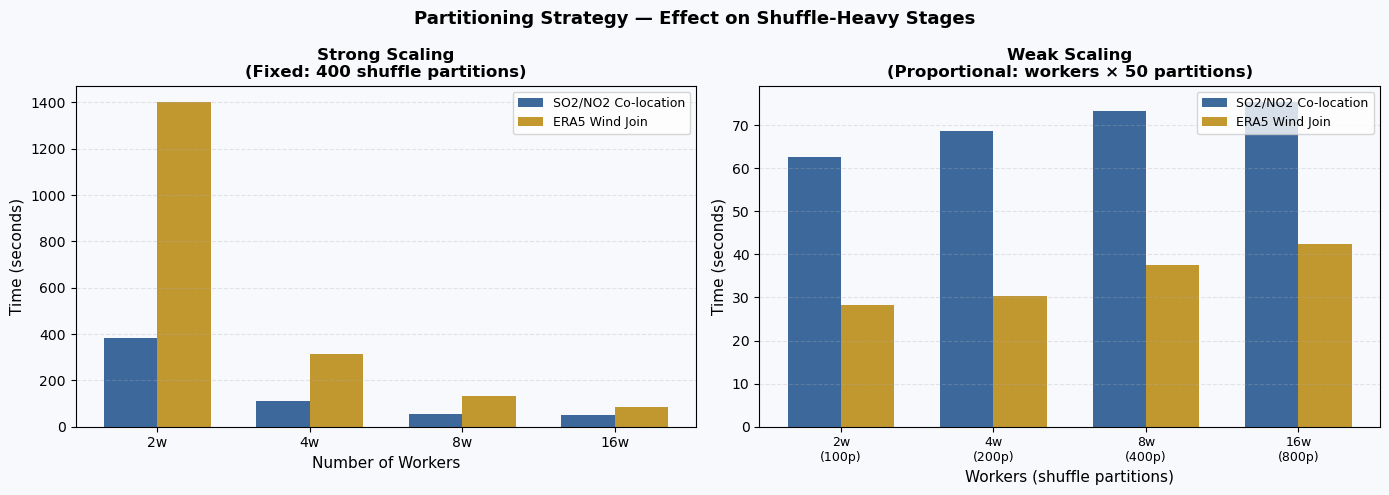

In [13]:
# Visualise partitioning strategy effect on shuffle stages
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F7F9FC')
for ax in axes:
    ax.set_facecolor('#F7F9FC')
fig.suptitle('Partitioning Strategy — Effect on Shuffle-Heavy Stages',
             fontsize=13, fontweight='bold')

shuffle_stages = ['stage2_colocation', 'stage3_era5_join']
shuffle_labels = ['SO2/NO2 Co-location', 'ERA5 Wind Join']
shuffle_colors = ['#1B4F8A', '#B8860B']

# Plot 1: Strong scaling , fixed 400 partitions
x = np.arange(len(workers))
width = 0.35
for i, (stage, label, color) in enumerate(zip(shuffle_stages, shuffle_labels, shuffle_colors)):
    times = [strong_results[w]['timings'][stage] for w in workers]
    offset = (i - 0.5) * width
    bars = axes[0].bar(x + offset, times, width, label=label, color=color, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'{w}w' for w in workers])
axes[0].set_xlabel('Number of Workers', fontsize=11)
axes[0].set_ylabel('Time (seconds)', fontsize=11)
axes[0].set_title('Strong Scaling\n(Fixed: 400 shuffle partitions)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, linestyle='--', axis='y')

# Plot 2: Weak scaling , proportional partitions
weak_workers_list = [k[0] for k in weak_keys]
weak_partitions   = [k[0] * 50 for k in weak_keys]
x2 = np.arange(len(weak_keys))
x2_labels = [f'{w}w\n({w*50}p)' for w in weak_workers_list]
for i, (stage, label, color) in enumerate(zip(shuffle_stages, shuffle_labels, shuffle_colors)):
    times = [weak_results[k]['timings'][stage] for k in weak_keys]
    offset = (i - 0.5) * width
    axes[1].bar(x2 + offset, times, width, label=label, color=color, alpha=0.85)
axes[1].set_xticks(x2)
axes[1].set_xticklabels(x2_labels, fontsize=9)
axes[1].set_xlabel('Workers (shuffle partitions)', fontsize=11)
axes[1].set_ylabel('Time (seconds)', fontsize=11)
axes[1].set_title('Weak Scaling\n(Proportional: workers × 50 partitions)', fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, linestyle='--', axis='y')

plt.tight_layout()
plt.savefig('partitioning_strategy_plot.png', dpi=150, bbox_inches='tight')
plt.show()
